In [2]:
import numpy as np
import matplotlib.pyplot as plt

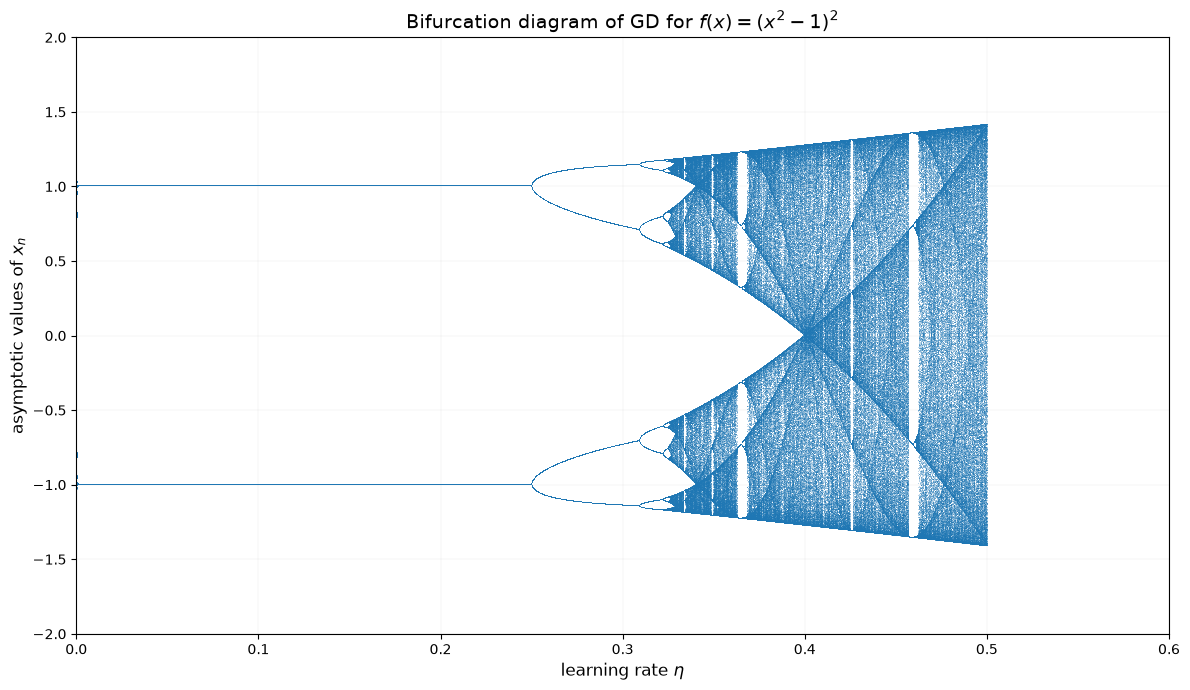

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# f(x) = (x^2 - 1)^2 に対する勾配降下法写像
# x_{n+1} = x_n - eta * f'(x_n)
#         = x_n - eta * 4x_n(x_n^2 - 1)
#         = x_n + 4 eta x_n(1 - x_n^2)
def F(x, eta):
    return x + 4.0 * eta * x * (1.0 - x * x)


# ----------------------------
# パラメータ設定
# ----------------------------

eta_min = 0.0
eta_max = 0.6
num_eta = 3000

n_burn = 1000   # 捨てる反復回数
n_keep = 150    # 描画する反復回数

escape_threshold = 1e3  # 発散判定

etas = np.linspace(eta_min, eta_max, num_eta)

# 複数の初期点を用意（logistic_bifurcation のスタイルに合わせる）
x0s = [-1.2, -0.5, 0.5, 1.2]


# ----------------------------
# 分岐図用データを作る
# ----------------------------

eta_values = []
x_values = []

for x0 in x0s:
    for eta in etas:
        x = x0
        
        # 過渡部分を捨てる
        converged = True
        for _ in range(n_burn):
            x = F(x, eta)
            if not np.isfinite(x) or np.abs(x) > escape_threshold:
                converged = False
                break
        
        if not converged:
            continue
        
        # 後半の軌道を保存
        for _ in range(n_keep):
            x = F(x, eta)
            if not np.isfinite(x) or np.abs(x) > escape_threshold:
                break
            eta_values.append(eta)
            x_values.append(x)


# ----------------------------
# 描画
# ----------------------------

plt.figure(figsize=(12, 7))
plt.plot(eta_values, x_values, ",", alpha=0.3, markersize=0.5)

plt.xlabel(r"learning rate $\eta$", fontsize=12)
plt.ylabel(r"asymptotic values of $x_n$", fontsize=12)
plt.title(r"Bifurcation diagram of GD for $f(x)=(x^2-1)^2$", fontsize=14)

plt.xlim(eta_min, eta_max)
plt.ylim(-2, 2)

plt.grid(True, linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.show()
